# Automated Casting Defect Detection Using Deep Learning and Computer Vision

**Original notebook version for team implementation**

This notebook builds an end-to-end casting product defect detection pipeline using:

- Detailed exploratory data analysis (EDA)
- Image quality checks and duplicate checks
- Data augmentation and efficient `tf.data` pipeline
- Baseline CNN model
- Transfer learning comparison using MobileNetV2, EfficientNetB0, DenseNet121 and Xception
- Fine-tuning of the best model
- Full test evaluation with confusion matrix and classification report
- Grad-CAM explainability
- Saving the best model for deployment

> Dataset expected structure:
>
> ```
> casting_data/
> └── casting_data/
>     ├── train/
>     │   ├── def_front/
>     │   └── ok_front/
>     └── test/
>         ├── def_front/
>         └── ok_front/
> ```
>
> On Kaggle, the usual path is:
>
> `/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data`


## 1. Team Work Division

Because this is a team project with 5 members, the notebook is organised so each person can clearly show contribution.

| Member | Main Responsibility | Evidence to Save |
|---|---|---|
| Member 1 | Dataset loading, cleaning, EDA and image analysis | EDA plots, class distribution, duplicate/corrupt image check |
| Member 2 | Baseline CNN and MobileNetV2 model | Training curves, metrics, saved model logs |
| Member 3 | EfficientNetB0 / DenseNet121 / Xception model training | Model comparison table |
| Member 4 | Test evaluation, confusion matrix, error analysis and Grad-CAM | Classification report, Grad-CAM images |
| Member 5 | Best model saving, deployment preparation and final integration | Saved model, README, Gradio/Hugging Face app files |


In [1]:

# 2. Libraries and setup


import os
import time
import json
import math
import hashlib
import random
import pathlib
import warnings
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.17.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:

# 3. Dataset paths


# Change this only if your dataset is stored somewhere else.
DATA_ROOT = pathlib.Path("/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data")

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

CLASS_NAMES = ["def_front", "ok_front"]

for folder in [TRAIN_DIR, TEST_DIR]:
    if not folder.exists():
        raise FileNotFoundError(f"Dataset folder not found: {folder}")

for cls in CLASS_NAMES:
    assert (TRAIN_DIR / cls).exists(), f"Missing training class folder: {cls}"
    assert (TEST_DIR / cls).exists(), f"Missing test class folder: {cls}"

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)


Train directory: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train
Test directory: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test


## 4. Exploratory Data Analysis

This section gives detailed evidence that the team understands the image dataset before training. It checks:

- Class counts
- Train/test distribution
- Image size distribution
- File extensions
- Corrupted images
- Duplicate images
- Random visual samples
- Average image appearance
- Pixel intensity distribution


In [3]:

# 4.1 Build image inventory dataframe


def collect_image_records(root_dir, split_name):
    records = []
    for label in CLASS_NAMES:
        label_dir = pathlib.Path(root_dir) / label
        for img_path in label_dir.glob("*"):
            if img_path.is_file():
                records.append({
                    "split": split_name,
                    "label": label,
                    "path": str(img_path),
                    "filename": img_path.name,
                    "extension": img_path.suffix.lower()
                })
    return records

records = []
records.extend(collect_image_records(TRAIN_DIR, "train"))
records.extend(collect_image_records(TEST_DIR, "test"))

df = pd.DataFrame(records)
print("Total image files:", len(df))
display(df.head())


Total image files: 7348


,split,label,path,filename,extension
0,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_6388.jpeg,.jpeg
1,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3139.jpeg,.jpeg
2,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3376.jpeg,.jpeg
3,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_9191.jpeg,.jpeg
4,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3431.jpeg,.jpeg


In [4]:

# 4.2 Class distribution table


count_table = (
    df.groupby(["split", "label"])
      .size()
      .reset_index(name="image_count")
      .sort_values(["split", "label"])
)

display(count_table)

pivot_counts = count_table.pivot(index="label", columns="split", values="image_count").fillna(0).astype(int)
display(pivot_counts)


,split,label,image_count
0,test,def_front,453
1,test,ok_front,262
2,train,def_front,3758
3,train,ok_front,2875


split,test,train
label,,
def_front,453,3758
ok_front,262,2875


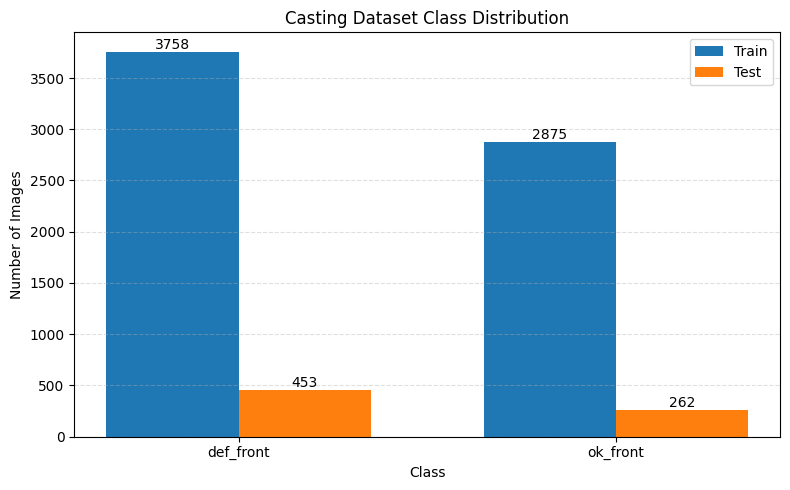

In [5]:

# 4.3 Class distribution bar chart


labels = pivot_counts.index.tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

train_values = pivot_counts["train"].values if "train" in pivot_counts.columns else np.zeros(len(labels))
test_values = pivot_counts["test"].values if "test" in pivot_counts.columns else np.zeros(len(labels))

bars1 = ax.bar(x - width/2, train_values, width, label="Train")
bars2 = ax.bar(x + width/2, test_values, width, label="Test")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            str(int(bar.get_height())),
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_title("Casting Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [6]:

# 4.4 Image readability, dimensions and corrupt file check


def inspect_image(path):
    img = cv2.imread(path)
    if img is None:
        return pd.Series({
            "readable": False,
            "height": np.nan,
            "width": np.nan,
            "channels": np.nan
        })
    h, w = img.shape[:2]
    c = img.shape[2] if len(img.shape) == 3 else 1
    return pd.Series({
        "readable": True,
        "height": h,
        "width": w,
        "channels": c
    })

image_meta = df["path"].apply(inspect_image)
df = pd.concat([df, image_meta], axis=1)

print("Unreadable / corrupted images:", (~df["readable"]).sum())
display(df.groupby(["split", "label", "readable"]).size().reset_index(name="count"))
display(df[["height", "width", "channels"]].describe())


Unreadable / corrupted images: 0


,split,label,readable,count
0,test,def_front,True,453
1,test,ok_front,True,262
2,train,def_front,True,3758
3,train,ok_front,True,2875


,height,width,channels
count,7348.0,7348.0,7348.0
mean,300.0,300.0,3.0
std,0.0,0.0,0.0
min,300.0,300.0,3.0
25%,300.0,300.0,3.0
50%,300.0,300.0,3.0
75%,300.0,300.0,3.0
max,300.0,300.0,3.0


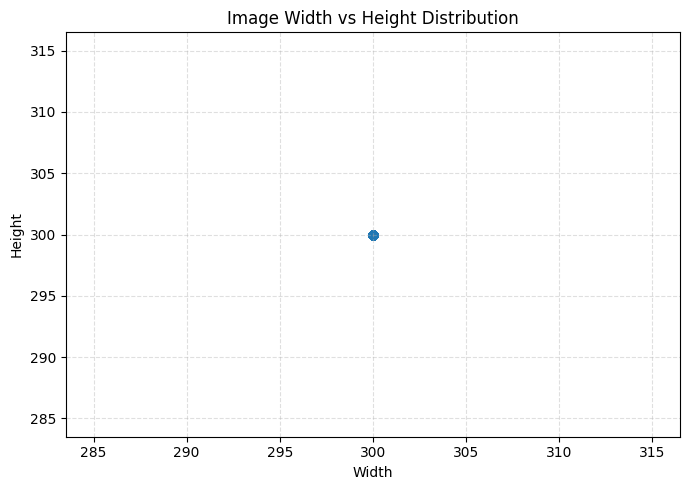

,width,height,count
0,300,300,7348


In [7]:

# 4.5 Image dimension distribution


valid_df = df[df["readable"]].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid_df["width"], valid_df["height"], alpha=0.4)
ax.set_title("Image Width vs Height Distribution")
ax.set_xlabel("Width")
ax.set_ylabel("Height")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

dimension_counts = (
    valid_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(dimension_counts.head(10))


In [8]:

# 4.6 Duplicate image check using hash


def file_hash(path, block_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            block = f.read(block_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()

# Hashing may take a little time but gives good data-quality evidence.
valid_df["md5_hash"] = valid_df["path"].apply(file_hash)

duplicate_groups = (
    valid_df.groupby("md5_hash")
    .filter(lambda x: len(x) > 1)
    .sort_values("md5_hash")
)

print("Number of duplicate file entries:", len(duplicate_groups))
print("Number of duplicate groups:", duplicate_groups["md5_hash"].nunique())
display(duplicate_groups[["split", "label", "filename", "path", "md5_hash"]].head(20))


Number of duplicate file entries: 128
Number of duplicate groups: 64


,split,label,filename,path,md5_hash
7194,test,ok_front,cast_ok_0_1022.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,033f2c3cd5e455eb823ad2c46d200437
4902,train,ok_front,cast_ok_0_1022.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,033f2c3cd5e455eb823ad2c46d200437
7190,test,ok_front,cast_ok_0_1095.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,05d1192be741dff53376c7b0df5d6c78
4881,train,ok_front,cast_ok_0_1095.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,05d1192be741dff53376c7b0df5d6c78
5946,train,ok_front,cast_ok_0_1173.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,06df33d7bd2257ae952f5af41f7be7ed
7288,test,ok_front,cast_ok_0_1173.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,06df33d7bd2257ae952f5af41f7be7ed
7327,test,ok_front,cast_ok_0_897.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,084250ff15695c700303993b8540c084
6375,train,ok_front,cast_ok_0_897.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,084250ff15695c700303993b8540c084
5051,train,ok_front,cast_ok_0_1171.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,0ed8b2ddda0187e6bc96459678326b76
7208,test,ok_front,cast_ok_0_1171.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,0ed8b2ddda0187e6bc96459678326b76


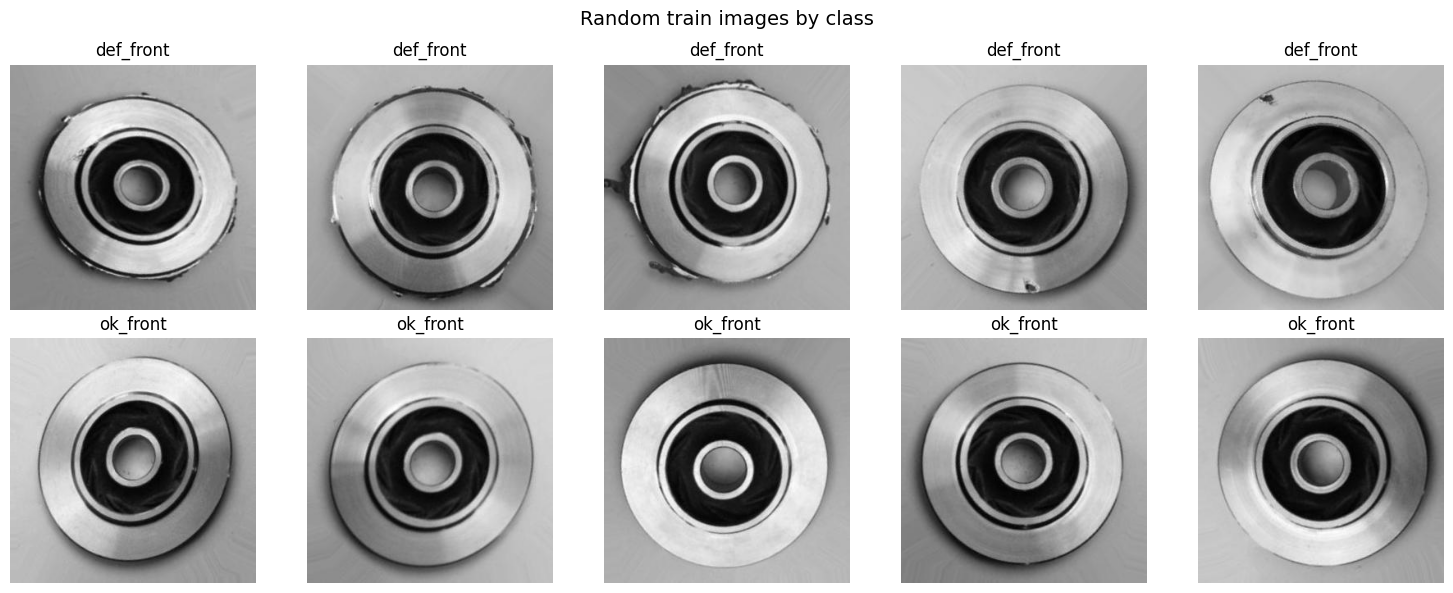

In [9]:

# 4.7 Random sample images from each class


def show_random_samples(dataframe, split="train", samples_per_class=5):
    fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(samples_per_class * 3, 6))
    if len(CLASS_NAMES) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, label in enumerate(CLASS_NAMES):
        subset = dataframe[(dataframe["split"] == split) & (dataframe["label"] == label) & (dataframe["readable"])]
        chosen = subset.sample(min(samples_per_class, len(subset)), random_state=SEED)
        for col_idx, (_, row) in enumerate(chosen.iterrows()):
            img = cv2.imread(row["path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis("off")
            axes[row_idx, col_idx].set_title(label)
    plt.suptitle(f"Random {split} images by class", fontsize=14)
    plt.tight_layout()
    plt.show()

show_random_samples(valid_df, split="train", samples_per_class=5)


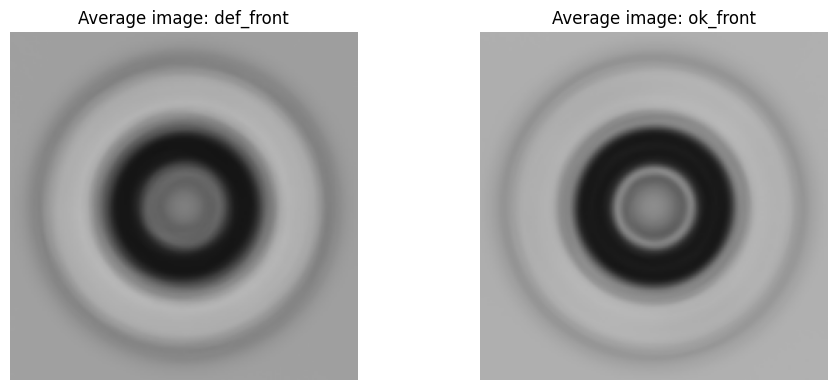

In [10]:

# 4.8 Average image by class


def average_image_for_label(dataframe, label, split="train", image_size=(224, 224), max_images=500):
    subset = dataframe[(dataframe["split"] == split) & (dataframe["label"] == label) & (dataframe["readable"])]
    subset = subset.sample(min(max_images, len(subset)), random_state=SEED)

    accumulator = np.zeros((image_size[0], image_size[1], 3), dtype=np.float64)
    count = 0

    for path in subset["path"]:
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)
        accumulator += img
        count += 1

    if count == 0:
        return None
    return (accumulator / count).astype(np.uint8)

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(10, 4))
for i, label in enumerate(CLASS_NAMES):
    avg_img = average_image_for_label(valid_df, label)
    axes[i].imshow(avg_img)
    axes[i].axis("off")
    axes[i].set_title(f"Average image: {label}")
plt.tight_layout()
plt.show()


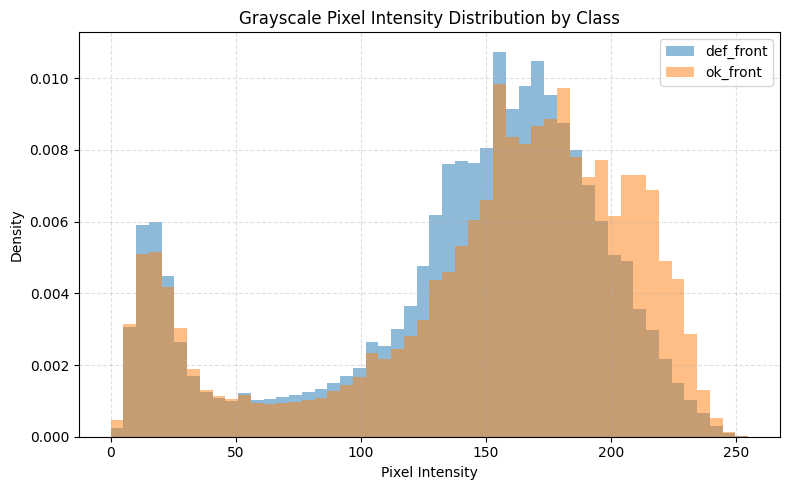

In [11]:

# 4.9 Pixel intensity distribution


def collect_pixel_intensities(dataframe, label, split="train", max_images=300, image_size=(128, 128)):
    subset = dataframe[(dataframe["split"] == split) & (dataframe["label"] == label) & (dataframe["readable"])]
    subset = subset.sample(min(max_images, len(subset)), random_state=SEED)
    values = []

    for path in subset["path"]:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, image_size)
        values.extend(img.flatten())

    return np.array(values)

fig, ax = plt.subplots(figsize=(8, 5))
for label in CLASS_NAMES:
    pixels = collect_pixel_intensities(valid_df, label)
    ax.hist(pixels, bins=50, alpha=0.5, density=True, label=label)

ax.set_title("Grayscale Pixel Intensity Distribution by Class")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Data Pipeline

This notebook uses `tf.keras.utils.image_dataset_from_directory` instead of `ImageDataGenerator`. This makes the pipeline more modern, reproducible and efficient.

Important differences from many common solutions:

- Uses `tf.data`
- Uses binary labels with sigmoid output
- Uses caching and prefetching
- Uses model-specific preprocessing inside each model
- Uses a model registry for fair comparison


In [12]:

# 5.1 Create tf.data datasets


IMG_SIZE = (299, 299)
BATCH_SIZE = 32
VAL_SPLIT = 0.20

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Class names:", train_ds.class_names)


Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.
Class names: ['def_front', 'ok_front']


In [13]:

# 5.2 Performance optimisation


AUTOTUNE = tf.data.AUTOTUNE

# Keep an unaugmented test dataset.
train_ds_fast = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds_fast = val_ds.cache().prefetch(AUTOTUNE)
test_ds_fast = test_ds.cache().prefetch(AUTOTUNE)


In [14]:

# 5.3 Class weights


y_train_all = []
for _, y_batch in train_ds:
    y_train_all.extend(y_batch.numpy().astype(int).flatten())

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_all),
    y=np.array(y_train_all)
)

CLASS_WEIGHTS = {int(i): float(w) for i, w in enumerate(class_weight_values)}
print("Class weights:", CLASS_WEIGHTS)


Class weights: {0: 0.8847949316438813, 1: 1.1496967071057191}


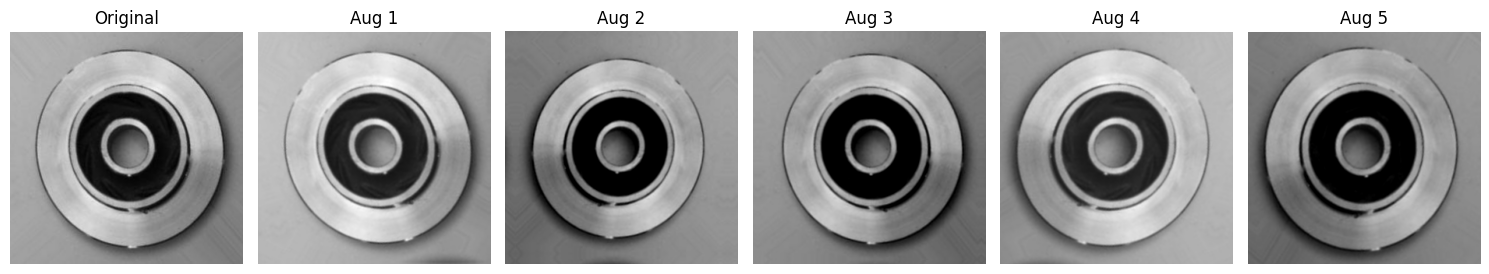

In [15]:

# 5.4 Data augmentation preview


augmentation_layer = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
        layers.RandomBrightness(0.10),
    ],
    name="casting_augmentation"
)

for images, labels in train_ds.take(1):
    sample_image = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_image[0].numpy().astype("uint8"))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    aug_img = augmentation_layer(sample_image, training=True)
    axes[i].imshow(tf.cast(aug_img[0], tf.uint8))
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 6. Model Building Functions

We will train several models using a consistent evaluation approach:

1. Custom CNN baseline
2. MobileNetV2 transfer learning
3. EfficientNetB0 transfer learning
4. DenseNet121 transfer learning
5. Xception transfer learning

The final selected model is based on validation and test performance, not a pre-decided architecture.


In [16]:

# 6.1 Output folders


OUTPUT_DIR = pathlib.Path("/kaggle/working/casting_defect_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

for folder in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR)


Output folder: /kaggle/working/casting_defect_outputs


In [17]:

# 6.2 Common plotting function


def plot_training_history(history, model_name):
    hist = pd.DataFrame(history.history)

    fig, ax = plt.subplots(figsize=(8, 5))
    if "binary_accuracy" in hist:
        ax.plot(hist["binary_accuracy"], label="Training Accuracy")
    if "val_binary_accuracy" in hist:
        ax.plot(hist["val_binary_accuracy"], label="Validation Accuracy")
    ax.set_title(f"{model_name}: Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{model_name}_accuracy.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist["loss"], label="Training Loss")
    ax.plot(hist["val_loss"], label="Validation Loss")
    ax.set_title(f"{model_name}: Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{model_name}_loss.png", dpi=150)
    plt.show()


In [18]:

# 6.3 Common metrics and callbacks


def compile_binary_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

def make_callbacks(model_name):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / f"{model_name}_best.keras"),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.CSVLogger(str(REPORT_DIR / f"{model_name}_training_log.csv"))
    ]


In [19]:

# 6.4 Baseline CNN model


def build_custom_cnn(input_shape=(299, 299, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = augmentation_layer(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="CustomCNN")
    return compile_binary_model(model, learning_rate=1e-3)


In [20]:
# =========================
# 6.5 Transfer learning model builder
# =========================

APPLICATIONS = {
    "MobileNetV2": {
        "constructor": keras.applications.MobileNetV2,
        "preprocess": keras.applications.mobilenet_v2.preprocess_input
    },
    "EfficientNetB0": {
        "constructor": keras.applications.EfficientNetB0,
        "preprocess": keras.applications.efficientnet.preprocess_input
    },
    "DenseNet121": {
        "constructor": keras.applications.DenseNet121,
        "preprocess": keras.applications.densenet.preprocess_input
    },
    "Xception": {
        "constructor": keras.applications.Xception,
        "preprocess": keras.applications.xception.preprocess_input
    }
}

def build_transfer_model(model_name, input_shape=(299, 299, 3), train_base=False, dropout_rate=0.35):
    item = APPLICATIONS[model_name]
    base = item["constructor"](
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base.trainable = train_base

    inputs = keras.Input(shape=input_shape)
    x = augmentation_layer(inputs)
    x = layers.Lambda(item["preprocess"], name=f"{model_name}_preprocess")(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return compile_binary_model(model, learning_rate=1e-3)


## 7. Train and Compare Models

The following training loop gives each model the same dataset and similar training settings. This makes the comparison fairer.

> Tip: If Kaggle GPU time is limited, first run the baseline CNN + Xception + EfficientNetB0. Then train the remaining models if time allows.



Training model: CustomCNN
Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - auc: 0.4956 - binary_accuracy: 0.5077 - loss: 0.7168 - precision: 0.4344 - recall: 0.4398
Epoch 1: val_auc improved from -inf to 0.50000, saving model to /kaggle/working/casting_defect_outputs/models/CustomCNN_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - auc: 0.4955 - binary_accuracy: 0.5077 - loss: 0.7167 - precision: 0.4344 - recall: 0.4395 - val_auc: 0.5000 - val_binary_accuracy: 0.4276 - val_loss: 0.6942 - val_precision: 0.4276 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - auc: 0.4884 - binary_accuracy: 0.4655 - loss: 0.6932 - precision: 0.4362 - recall: 0.7902
Epoch 2: val_auc did not improve from 0.50000
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - auc: 0.4884 - binary_accuracy: 0.4655 - loss: 0.6932 - precision: 0.4361 - recall: 0.7894 - val_auc: 0.5000 - val_binary_accuracy: 0.5724 - val_loss: 0.6929 - val_precision: 0.0000e+00 - val

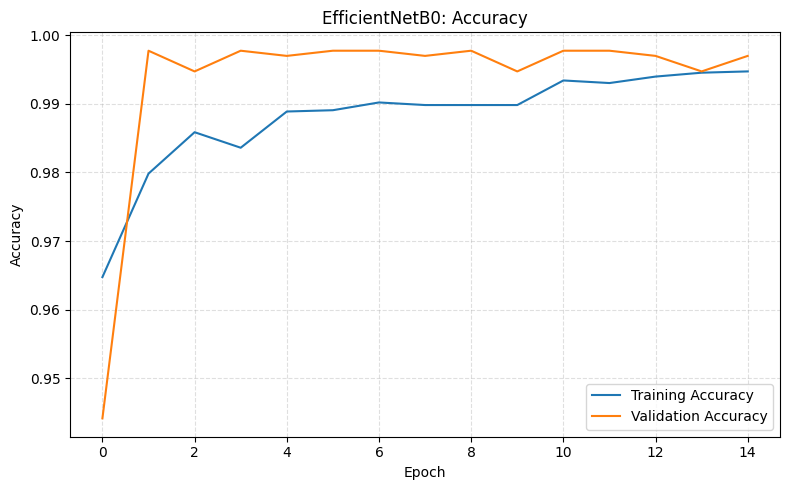

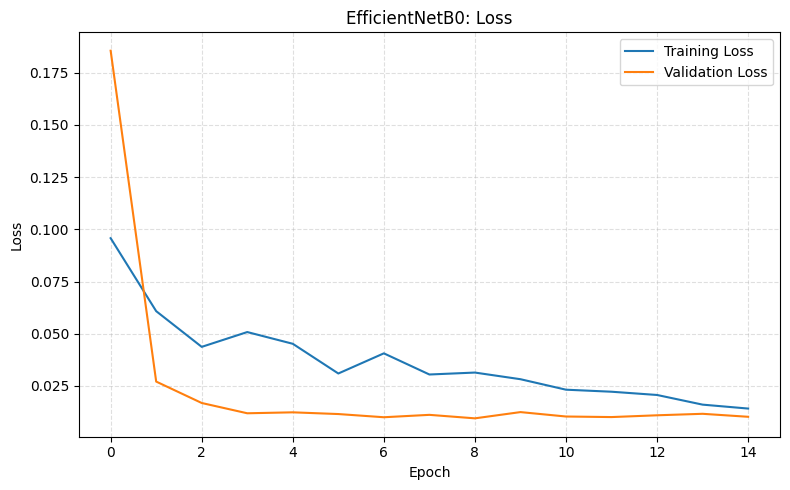

EfficientNetB0 training time: 4.47 minutes

Training model: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - auc: 0.9795 - binary_accuracy: 0.9454 - loss: 0.1335 - precision: 0.9206 - recall: 0.9574
Epoch 1: val_auc improved from -inf to 0.99917, saving model to /kaggle/working/casting_defect_outputs/models/DenseNet121_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 51s 216ms/step - auc: 0.9796 - binary_accuracy: 0.9456 - loss: 0.1331 - precision: 0.9208 - recall: 0.9575 - val_auc: 0.9992 - val_binary_accuracy: 0.9148 - val_loss: 0.1927 - val_precision: 0.9978 - val_recall: 0.8025 - learning_rate: 0.0010
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - auc: 0.9992 - binary_accuracy: 0.9918 - loss: 0.0239 - precision: 0.9892 - recall: 0.9926
Epoch 2: val_auc improved from 0.99917 to 0.99981, saving model to /kaggle/working/casting_defect_outputs/models/DenseNet121_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step 

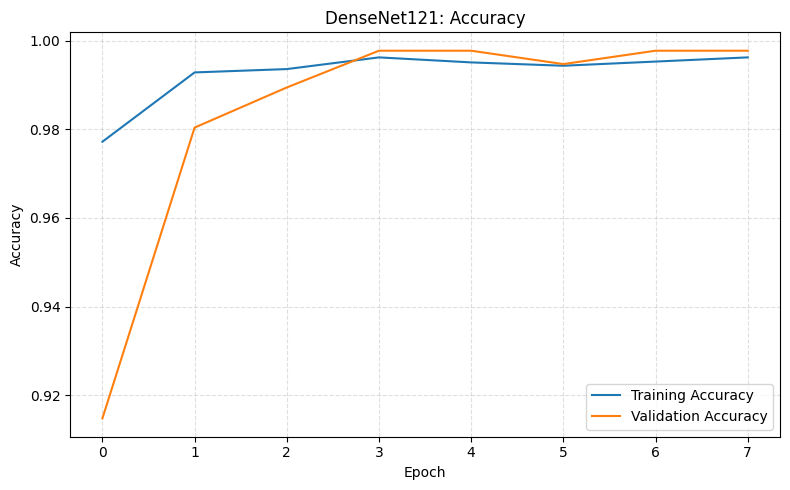

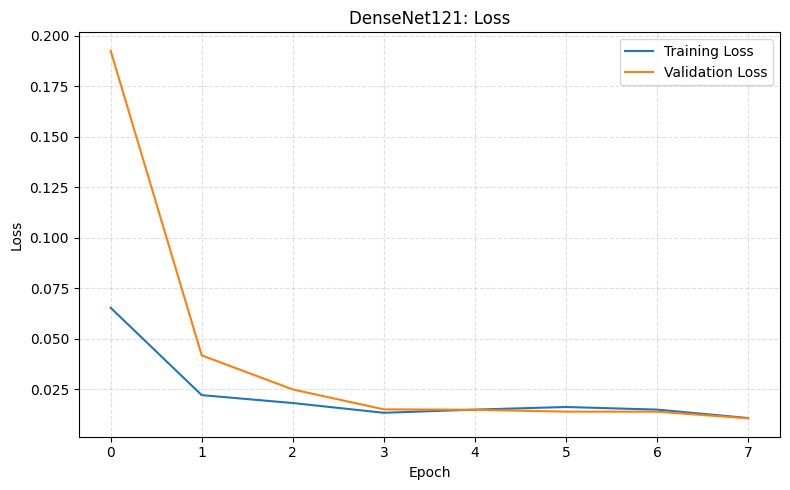

DenseNet121 training time: 4.11 minutes

Training model: Xception
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - auc: 0.9722 - binary_accuracy: 0.9162 - loss: 0.1802 - precision: 0.8768 - recall: 0.9510
Epoch 1: val_auc improved from -inf to 0.99879, saving model to /kaggle/working/casting_defect_outputs/models/Xception_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 45s 230ms/step - auc: 0.9724 - binary_accuracy: 0.9165 - loss: 0.1797 - precision: 0.8772 - recall: 0.9512 - val_auc: 0.9988 - val_binary_accuracy: 0.9563 - val_loss: 0.1775 - val_precision: 0.9961 - val_recall: 0.9012 - learning_rate: 0.0010
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - auc: 0.9963 - binary_accuracy: 0.9798 - loss: 0.0607 - precision: 0.9757 - recall: 0.9789
Epoch 2: val_auc improved from 0.99879 to 0.99899, saving model to /kaggle/working/casting_defect_outputs/models/Xception_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 35s 208ms/step - auc: 0.9963 - binary_accuracy: 0.9798 - loss: 0.0607 - precision: 0.9756

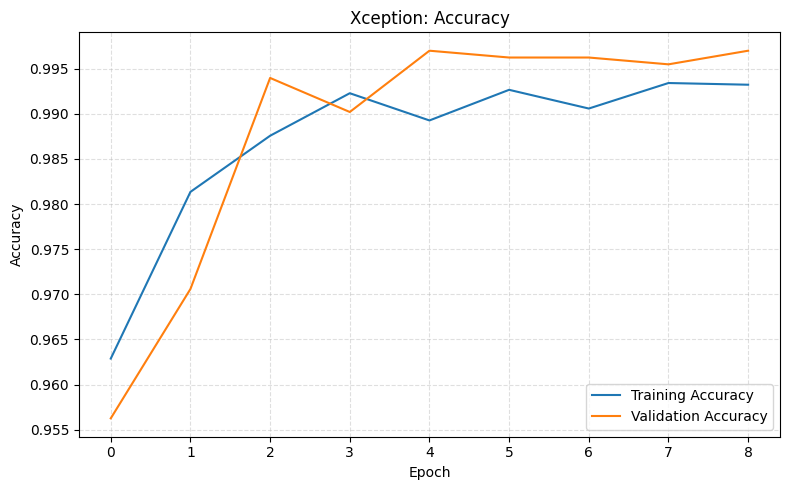

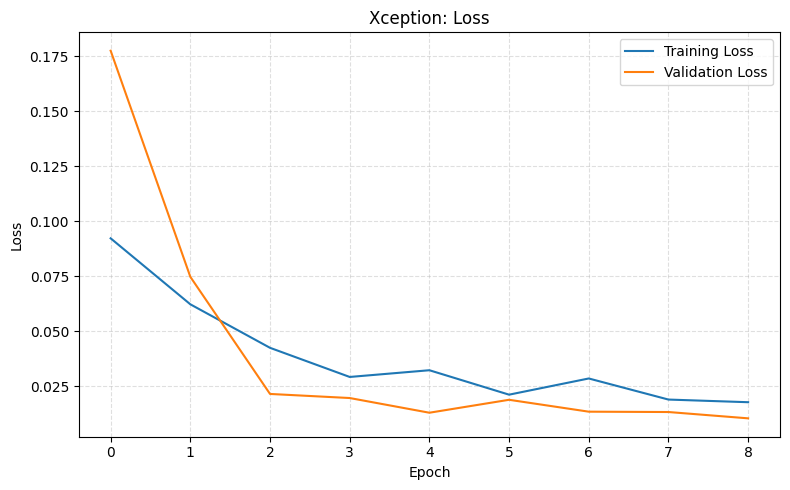

Xception training time: 5.26 minutes


In [21]:

# 7.1 Train selected models


EPOCHS_INITIAL = 15

model_names_to_train = [
    "CustomCNN",
    "MobileNetV2",
    "EfficientNetB0",
    "DenseNet121",
    "Xception"
]

histories = {}
trained_models = {}

for model_name in model_names_to_train:
    print("\n" + "="*80)
    print(f"Training model: {model_name}")
    print("="*80)

    if model_name == "CustomCNN":
        model = build_custom_cnn(input_shape=IMG_SIZE + (3,))
    else:
        model = build_transfer_model(model_name, input_shape=IMG_SIZE + (3,), train_base=False)

    start = time.time()
    history = model.fit(
        train_ds_fast,
        validation_data=val_ds_fast,
        epochs=EPOCHS_INITIAL,
        callbacks=make_callbacks(model_name),
        class_weight=CLASS_WEIGHTS,
        verbose=1
    )
    training_time = time.time() - start

    histories[model_name] = history
    trained_models[model_name] = model

    plot_training_history(history, model_name)
    print(f"{model_name} training time: {training_time/60:.2f} minutes")


In [22]:

# 7.2 Validation comparison table


comparison_rows = []

for model_name, history in histories.items():
    hist = pd.DataFrame(history.history)
    best_epoch = hist["val_auc"].idxmax()
    comparison_rows.append({
        "model": model_name,
        "best_epoch": int(best_epoch + 1),
        "val_accuracy": float(hist.loc[best_epoch, "val_binary_accuracy"]),
        "val_precision": float(hist.loc[best_epoch, "val_precision"]),
        "val_recall": float(hist.loc[best_epoch, "val_recall"]),
        "val_auc": float(hist.loc[best_epoch, "val_auc"]),
        "val_loss": float(hist.loc[best_epoch, "val_loss"])
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("val_auc", ascending=False)
display(comparison_df)

comparison_df.to_csv(REPORT_DIR / "validation_model_comparison.csv", index=False)
best_model_name = comparison_df.iloc[0]["model"]
print("Best model based on validation AUC:", best_model_name)


,model,best_epoch,val_accuracy,val_precision,val_recall,val_auc,val_loss
4,Xception,4,0.990196,0.996416,0.980600,0.999913,0.019687
2,EfficientNetB0,15,0.996983,0.994728,0.998236,0.999898,0.010253
1,MobileNetV2,5,0.990950,0.992895,0.985891,0.999889,0.017879
3,DenseNet121,3,0.989442,0.998198,0.977072,0.999884,0.024875
0,CustomCNN,1,0.427602,0.427602,1.000000,0.500000,0.694165


Best model based on validation AUC: Xception


## 8. Fine-Tuning the Best Transfer Model

The best transfer-learning model can be fine-tuned by unfreezing only the upper part of the feature extractor. Fine-tuning should use a very small learning rate.

If the best validation model is the custom CNN, this section automatically chooses Xception for fine-tuning because fine-tuning applies to pre-trained models.


In [ ]:

# 8.1 Fine-tune best transfer model


fine_tune_candidate = best_model_name if best_model_name != "CustomCNN" else "Xception"
print("Fine-tuning candidate:", fine_tune_candidate)

fine_model = build_transfer_model(fine_tune_candidate, input_shape=IMG_SIZE + (3,), train_base=True, dropout_rate=0.40)

# Freeze most layers and train only the last part of the backbone.
base_model = None
for layer in fine_model.layers:
    if isinstance(layer, keras.Model):
        base_model = layer
        break

if base_model is not None:
    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * 0.75)
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    for layer in base_model.layers[freeze_until:]:
        layer.trainable = True

    print(f"Base model layers: {total_layers}")
    print(f"Frozen layers: {freeze_until}")
    print(f"Fine-tuned layers: {total_layers - freeze_until}")

fine_model = compile_binary_model(fine_model, learning_rate=1e-5)

fine_history = fine_model.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=10,
    callbacks=make_callbacks(f"{fine_tune_candidate}_fine_tuned"),
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

histories[f"{fine_tune_candidate}_fine_tuned"] = fine_history
trained_models[f"{fine_tune_candidate}_fine_tuned"] = fine_model

plot_training_history(fine_history, f"{fine_tune_candidate}_fine_tuned")


Fine-tuning candidate: Xception
Base model layers: 5
Frozen layers: 3
Fine-tuned layers: 2
Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - auc: 0.8699 - binary_accuracy: 0.7845 - loss: 0.4382 - precision: 0.7169 - recall: 0.8410
Epoch 1: val_auc improved from -inf to 0.98426, saving model to /kaggle/working/casting_defect_outputs/models/Xception_fine_tuned_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 156s 768ms/step - auc: 0.8704 - binary_accuracy: 0.7851 - loss: 0.4371 - precision: 0.7175 - recall: 0.8414 - val_auc: 0.9843 - val_binary_accuracy: 0.8974 - val_loss: 0.4059 - val_precision: 0.9865 - val_recall: 0.7707 - learning_rate: 1.0000e-05
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - auc: 0.9974 - binary_accuracy: 0.9759 - loss: 0.0724 - precision: 0.9599 - recall: 0.9860
Epoch 2: val_auc improved from 0.98426 to 0.99596, saving model to /kaggle/working/casting_defect_outputs/models/Xception_fine_tuned_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 123s 742ms/step - auc: 0.9

## 9. Test Set Evaluation

This section evaluates all trained models on the same held-out test set.

The final decision should consider:

- Accuracy
- Precision
- Recall
- F1-score
- AUC
- Confusion matrix
- Inference time
- Model size
- Explainability quality

For industrial defect detection, **recall for defective images is especially important** because missing a defective product is a serious quality risk.


In [ ]:

# 9.1 Helper functions for test evaluation


def get_true_labels(dataset):
    y_true = []
    for _, y_batch in dataset:
        y_true.extend(y_batch.numpy().astype(int).flatten())
    return np.array(y_true)

def predict_model(model, dataset):
    probabilities = model.predict(dataset, verbose=0).flatten()
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions

y_test = get_true_labels(test_ds_fast)
print("Test labels shape:", y_test.shape)
print("Label mapping:", {0: CLASS_NAMES[0], 1: CLASS_NAMES[1]})


In [25]:

# 9.2 Evaluate all models on the test data


test_rows = []

for model_name, model in trained_models.items():
    start = time.time()
    y_prob, y_pred = predict_model(model, test_ds_fast)
    infer_time = time.time() - start

    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = np.nan

    model_path = MODEL_DIR / f"{model_name}_final.keras"
    model.save(model_path)
    model_size_mb = model_path.stat().st_size / (1024 * 1024)

    test_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "auc": auc,
        "inference_time_seconds_total_test": infer_time,
        "avg_inference_ms_per_image": (infer_time / len(y_test)) * 1000,
        "saved_model_size_mb": model_size_mb
    })

test_results_df = pd.DataFrame(test_rows).sort_values(["f1_score", "recall", "auc"], ascending=False)
display(test_results_df)

test_results_df.to_csv(REPORT_DIR / "test_model_comparison.csv", index=False)

final_model_name = test_results_df.iloc[0]["model"]
final_model = trained_models[final_model_name]
print("Final selected model:", final_model_name)


,model,accuracy,precision,recall,f1_score,auc,inference_time_seconds_total_test,avg_inference_ms_per_image,saved_model_size_mb
5,Xception_fine_tuned,0.997203,0.996183,0.996183,0.996183,0.999975,5.125722,7.168843,244.999390
2,EfficientNetB0,0.990210,0.992278,0.980916,0.986564,0.999916,5.690012,7.958058,20.055041
1,MobileNetV2,0.990210,0.992278,0.980916,0.986564,0.999823,3.586071,5.015483,12.980692
3,DenseNet121,0.984615,1.000000,0.958015,0.978558,1.000000,10.226741,14.303135,31.310772
4,Xception,0.983217,0.992126,0.961832,0.976744,0.999545,5.757856,8.052945,86.143905
0,CustomCNN,0.366434,0.366434,1.000000,0.536336,0.564102,0.834655,1.167350,5.267455


Final selected model: Xception_fine_tuned


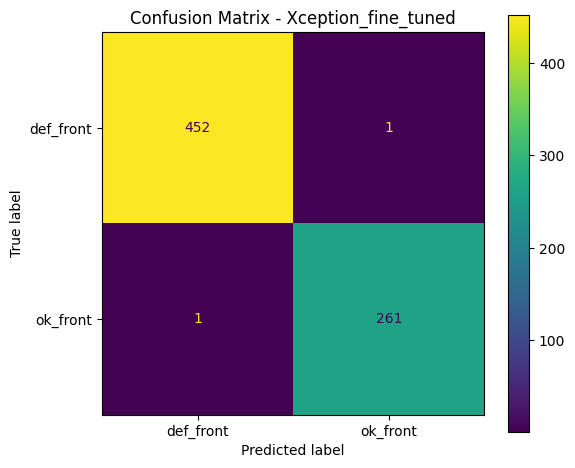

Classification Report:
              precision    recall  f1-score   support

   def_front     0.9978    0.9978    0.9978       453
    ok_front     0.9962    0.9962    0.9962       262

    accuracy                         0.9972       715
   macro avg     0.9970    0.9970    0.9970       715
weighted avg     0.9972    0.9972    0.9972       715

Final test accuracy: 99.72%


In [26]:

# 9.3 Confusion matrix and classification report for final model


final_probs, final_preds = predict_model(final_model, test_ds_fast)

cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, values_format="d", colorbar=True)
ax.set_title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"{final_model_name}_confusion_matrix.png", dpi=150)
plt.show()

print("Classification Report:")
print(classification_report(y_test, final_preds, target_names=CLASS_NAMES, digits=4))

with open(REPORT_DIR / f"{final_model_name}_classification_report.txt", "w") as f:
    f.write(classification_report(y_test, final_preds, target_names=CLASS_NAMES, digits=4))

print(f"Final test accuracy: {accuracy_score(y_test, final_preds) * 100:.2f}%")


Number of misclassified test images: 2


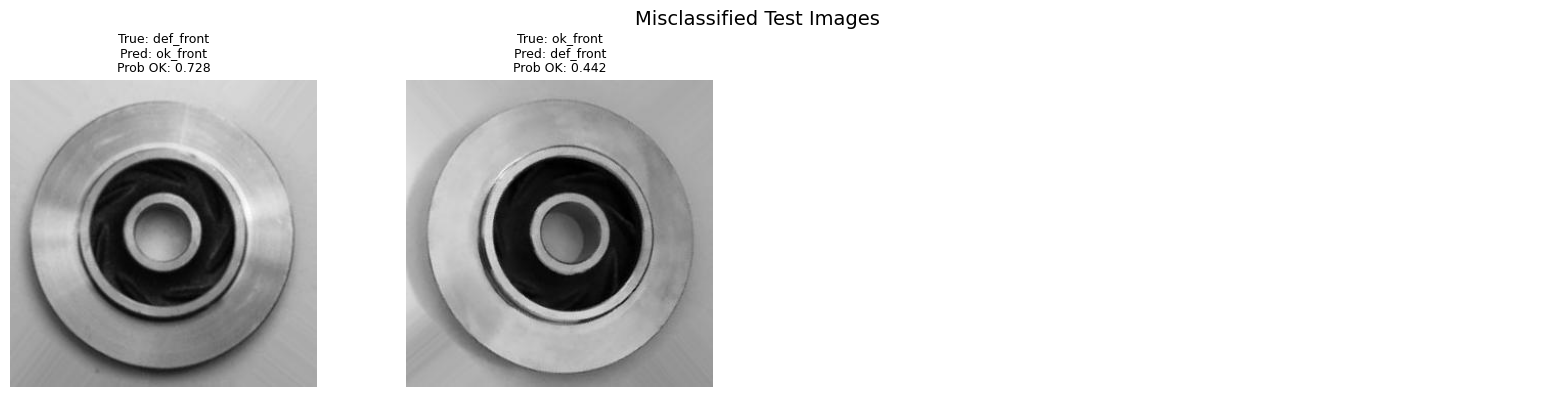

In [27]:

# 9.4 Error analysis: show misclassified images


test_file_paths = []
for label in CLASS_NAMES:
    for img_path in sorted((TEST_DIR / label).glob("*")):
        if img_path.is_file():
            test_file_paths.append(str(img_path))

# image_dataset_from_directory sorts by file path internally. 
# This ordering usually matches sorted class folders and sorted filenames.
error_indices = np.where(final_preds != y_test)[0]
print("Number of misclassified test images:", len(error_indices))

def show_misclassified(max_images=12):
    if len(error_indices) == 0:
        print("No misclassified images found for the final model.")
        return

    chosen = error_indices[:max_images]
    cols = 4
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, chosen):
        img_path = test_file_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"True: {CLASS_NAMES[int(y_test[idx])]}\nPred: {CLASS_NAMES[int(final_preds[idx])]}\nProb OK: {final_probs[idx]:.3f}",
            fontsize=9
        )

    for ax in axes[len(chosen):]:
        ax.axis("off")

    plt.suptitle("Misclassified Test Images", fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{final_model_name}_misclassified_examples.png", dpi=150)
    plt.show()

show_misclassified(max_images=12)


## 10. Grad-CAM Explainability

Grad-CAM helps show which image regions influenced a model prediction. This is useful for human-in-the-loop quality inspection.

For transfer learning models, Grad-CAM is usually applied to the final convolutional layer of the feature extractor.


In [34]:
# ============================================================
# 10.1 Grad-CAM utilities - FIXED FOR NESTED TRANSFER MODELS
# ============================================================

def find_last_conv_layer(model):
    """
    Finds a suitable final 4D feature-map layer.

    Returns:
        nested_model_name, conv_layer_name

    For transfer-learning models this will usually return something like:
        ('xception', 'block14_sepconv2_act')
    """

    # First inspect nested models such as Xception / MobileNet / ResNet
    for layer in reversed(model.layers):

        if isinstance(layer, keras.Model):

            for sub_layer in reversed(layer.layers):

                try:
                    output_shape = sub_layer.output.shape

                    if len(output_shape) == 4:
                        return layer.name, sub_layer.name

                except Exception:
                    continue

    # Otherwise search top-level model
    for layer in reversed(model.layers):

        try:
            if len(layer.output.shape) == 4:
                return None, layer.name

        except Exception:
            continue

    raise ValueError(
        "No suitable 4D convolutional feature layer was found."
    )


def call_layer_inference(layer, x):
    """
    Safely calls a layer in inference mode.
    """

    try:
        return layer(x, training=False)

    except TypeError:
        return layer(x)


def make_gradcam_heatmap(
    img_array,
    model,
    nested_model_name=None,
    conv_layer_name=None,
    class_index=None
):
    """
    Generate Grad-CAM heatmap.

    Works with:
        1. Normal CNN models
        2. Nested transfer-learning models such as Xception

    Supports binary sigmoid and multiclass outputs.
    """

    # Convert NumPy input to TensorFlow tensor
    img_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    # --------------------------------------------------------
    # CASE 1: Normal CNN / target layer at top level
    # --------------------------------------------------------

    if nested_model_name is None:

        conv_layer = model.get_layer(conv_layer_name)

        grad_model = keras.Model(
            inputs=model.inputs,
            outputs=[
                conv_layer.output,
                model.output
            ]
        )

        with tf.GradientTape() as tape:

            conv_outputs, predictions = grad_model(
                img_tensor,
                training=False
            )

            # Binary classification
            if predictions.shape[-1] == 1:

                probability = predictions[:, 0]

                if class_index is None:
                    class_index = int(
                        probability[0] >= 0.5
                    )

                if class_index == 1:
                    loss = probability
                else:
                    loss = 1.0 - probability

            # Multiclass classification
            else:

                if class_index is None:
                    class_index = tf.argmax(
                        predictions[0]
                    )

                loss = predictions[:, class_index]

    # --------------------------------------------------------
    # CASE 2: Nested model such as Xception
    # --------------------------------------------------------

    else:

        backbone = model.get_layer(
            nested_model_name
        )

        target_layer = backbone.get_layer(
            conv_layer_name
        )

        # IMPORTANT:
        # Build extractor INSIDE the backbone graph first.
        backbone_grad_model = keras.Model(
            inputs=backbone.inputs,
            outputs=[
                target_layer.output,
                backbone.output
            ],
            name="gradcam_backbone"
        )

        with tf.GradientTape() as tape:

            x = img_tensor

            conv_outputs = None

            # Re-run outer model layer-by-layer
            for layer in model.layers:

                # InputLayer does not need to be called
                if isinstance(layer, layers.InputLayer):
                    continue

                # When reaching Xception, obtain BOTH:
                # target feature map + normal backbone output
                if layer.name == nested_model_name:

                    conv_outputs, x = backbone_grad_model(
                        x,
                        training=False
                    )

                else:

                    x = call_layer_inference(
                        layer,
                        x
                    )

            predictions = x

            if conv_outputs is None:
                raise RuntimeError(
                    f"Could not reach nested model "
                    f"'{nested_model_name}'."
                )

            # In case model has multiple outputs
            if isinstance(predictions, (list, tuple)):
                predictions = predictions[0]

            # Binary sigmoid classification
            if predictions.shape[-1] == 1:

                probability = predictions[:, 0]

                if class_index is None:
                    class_index = int(
                        probability[0] >= 0.5
                    )

                # Explain the predicted class
                if class_index == 1:
                    loss = probability
                else:
                    loss = 1.0 - probability

            # Multiclass
            else:

                if class_index is None:
                    class_index = tf.argmax(
                        predictions[0]
                    )

                loss = predictions[:, class_index]

    # --------------------------------------------------------
    # Calculate gradients
    # --------------------------------------------------------

    grads = tape.gradient(
        loss,
        conv_outputs
    )

    if grads is None:
        raise RuntimeError(
            "Gradients are None. The selected feature layer "
            "is not connected to the model prediction."
        )

    # Average gradient for each feature-map channel
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Grad-CAM uses positive influence
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize to 0-1
    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()


def overlay_heatmap(
    original_img,
    heatmap,
    alpha=0.45
):
    """
    Overlay Grad-CAM heatmap on original RGB image.
    """

    # Resize heatmap to image dimensions
    heatmap = cv2.resize(
        heatmap,
        (
            original_img.shape[1],
            original_img.shape[0]
        )
    )

    # Convert from 0-1 to 0-255
    heatmap_uint8 = np.uint8(
        255 * np.clip(heatmap, 0, 1)
    )

    # Apply JET colour map
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # OpenCV BGR -> RGB
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Make sure image is uint8
    original_uint8 = np.clip(
        original_img,
        0,
        255
    ).astype("uint8")

    # Overlay
    overlay = cv2.addWeighted(
        original_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay

Grad-CAM configuration
Nested model: xception
Target feature layer: block14_sepconv2_act


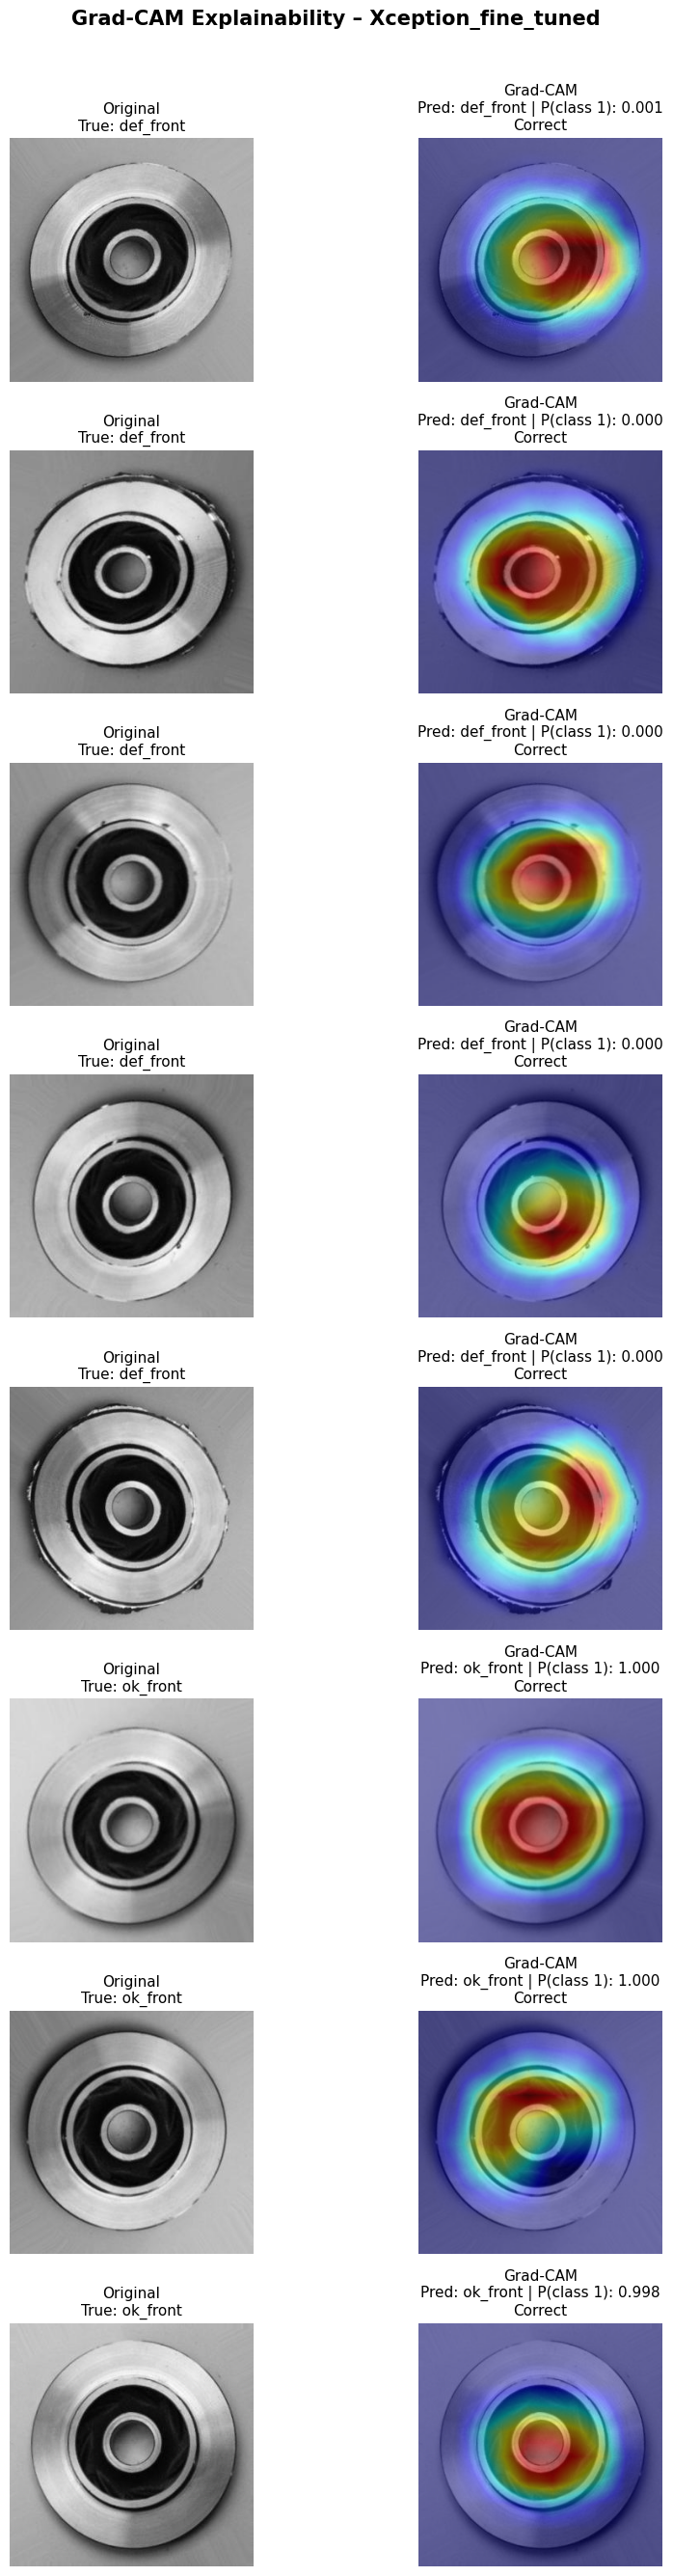


✓ Grad-CAM successfully generated.
✓ Saved to: /kaggle/working/casting_defect_outputs/plots/Xception_fine_tuned_gradcam_examples.png


In [35]:

# 10.2 Display Grad-CAM examples - FIXED


def load_image_for_model(
    path,
    image_size=IMG_SIZE
):
    """
    Load image in the same raw 0-255 format expected
    by an end-to-end model containing its own preprocessing.
    """

    img = keras.utils.load_img(
        path,
        target_size=image_size,
        color_mode="rgb"
    )

    arr = keras.utils.img_to_array(img)

    img_batch = np.expand_dims(
        arr,
        axis=0
    ).astype("float32")

    original = np.clip(
        arr,
        0,
        255
    ).astype("uint8")

    return img_batch, original


fig = None

try:


    # Find Grad-CAM target


    nested_name, last_conv_name = find_last_conv_layer(
        final_model
    )

    print("=" * 60)
    print("Grad-CAM configuration")
    print("=" * 60)

    print(
        "Nested model:",
        nested_name
    )

    print(
        "Target feature layer:",
        last_conv_name
    )

    print("=" * 60)


    # Select 8 representative test images


    number_of_examples = min(
        8,
        len(test_file_paths)
    )

    sample_indices = np.linspace(
        0,
        len(test_file_paths) - 1,
        number_of_examples,
        dtype=int
    )


    # Create plot


    fig, axes = plt.subplots(
        number_of_examples,
        2,
        figsize=(
            10,
            number_of_examples * 3.3
        )
    )

    # Handle case where only one sample exists
    if number_of_examples == 1:
        axes = np.expand_dims(
            axes,
            axis=0
        )


    # Generate Grad-CAM for each image


    for row, idx in enumerate(
        sample_indices
    ):

        img_path = test_file_paths[idx]

        img_batch, original = load_image_for_model(
            img_path
        )

        # Model prediction
        prediction = final_model(
            img_batch,
            training=False
        )

        prob = float(
            prediction.numpy().reshape(-1)[0]
        )

        pred_index = int(
            prob >= 0.5
        )

        true_index = int(
            y_test[idx]
        )

        pred_label = CLASS_NAMES[
            pred_index
        ]

        true_label = CLASS_NAMES[
            true_index
        ]


        # Generate Grad-CAM for predicted class


        heatmap = make_gradcam_heatmap(
            img_batch,
            final_model,
            nested_model_name=nested_name,
            conv_layer_name=last_conv_name,
            class_index=pred_index
        )

        overlay = overlay_heatmap(
            original,
            heatmap,
            alpha=0.45
        )


        # Original


        axes[row, 0].imshow(
            original
        )

        axes[row, 0].axis(
            "off"
        )

        axes[row, 0].set_title(
            f"Original\n"
            f"True: {true_label}",
            fontsize=11
        )


        # Grad-CAM


        axes[row, 1].imshow(
            overlay
        )

        axes[row, 1].axis(
            "off"
        )

        correctness = (
            "Correct"
            if pred_index == true_index
            else "Incorrect"
        )

        axes[row, 1].set_title(
            f"Grad-CAM\n"
            f"Pred: {pred_label} | "
            f"P(class 1): {prob:.3f}\n"
            f"{correctness}",
            fontsize=11
        )


    # Final plot


    plt.suptitle(
        f"Grad-CAM Explainability – {final_model_name}",
        fontsize=15,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()

    output_path = (
        PLOT_DIR /
        f"{final_model_name}_gradcam_examples.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print()
    print("✓ Grad-CAM successfully generated.")
    print(
        "✓ Saved to:",
        output_path
    )


except Exception as e:

    # Prevent the empty plot appearing when an exception happens
    if fig is not None:
        plt.close(fig)

    print()
    print("Grad-CAM could not be generated.")
    print()
    print(
        "Error type:",
        type(e).__name__
    )

    print(
        "Reason:",
        str(e)
    )

    raise

## 11. Save the Final Best Model and Metadata

This section saves the best model and supporting files for deployment or final submission.


In [30]:

# 11.1 Save final model and metadata


FINAL_MODEL_PATH = MODEL_DIR / "casting_defect_best_model.keras"
final_model.save(FINAL_MODEL_PATH)

metadata = {
    "project_title": "Automated Casting Defect Detection Using Deep Learning and Computer Vision",
    "final_model": final_model_name,
    "image_size": IMG_SIZE,
    "class_names": CLASS_NAMES,
    "label_mapping": {
        "0": CLASS_NAMES[0],
        "1": CLASS_NAMES[1]
    },
    "decision_threshold": 0.5,
    "created_at": datetime.now().isoformat(),
    "test_results": test_results_df.to_dict(orient="records")
}

with open(OUTPUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved final model to:", FINAL_MODEL_PATH)
print("Saved metadata to:", OUTPUT_DIR / "model_metadata.json")


Saved final model to: /kaggle/working/casting_defect_outputs/models/casting_defect_best_model.keras
Saved metadata to: /kaggle/working/casting_defect_outputs/model_metadata.json


In [31]:
# =========================
# 11.2 Export model comparison summary as markdown
# =========================

summary_md = f'''
# Casting Defect Detection Model Results

## Final Selected Model
**{final_model_name}**

## Test Results
{test_results_df.to_markdown(index=False)}

## Notes
- The same train/validation/test structure was used for each model.
- The final model was selected using F1-score, recall and AUC.
- Recall is important because missed defective casting products create serious quality risk.
- Grad-CAM visualisations were generated to support explainability and human review.
'''

with open(OUTPUT_DIR / "RESULTS_SUMMARY.md", "w") as f:
    f.write(summary_md)

print(summary_md)



# Casting Defect Detection Model Results

## Final Selected Model
**Xception_fine_tuned**

## Test Results
| model               |   accuracy |   precision |   recall |   f1_score |      auc |   inference_time_seconds_total_test |   avg_inference_ms_per_image |   saved_model_size_mb |
|:--------------------|-----------:|------------:|---------:|-----------:|---------:|------------------------------------:|-----------------------------:|----------------------:|
| Xception_fine_tuned |   0.997203 |    0.996183 | 0.996183 |   0.996183 | 0.999975 |                            5.12572  |                      7.16884 |             244.999   |
| EfficientNetB0      |   0.99021  |    0.992278 | 0.980916 |   0.986564 | 0.999916 |                            5.69001  |                      7.95806 |              20.055   |
| MobileNetV2         |   0.99021  |    0.992278 | 0.980916 |   0.986564 | 0.999823 |                            3.58607  |                      5.01548 |              12.9807 

## 12. Optional YOLO Classification Comparison

This section is optional. Run it only if your environment has the `ultralytics` package available and your dataset is arranged in a YOLO-compatible classification folder structure.

For classification, YOLO expects:

```
dataset_yolo/
├── train/
│   ├── def_front/
│   └── ok_front/
├── val/
│   ├── def_front/
│   └── ok_front/
└── test/
    ├── def_front/
    └── ok_front/
```

Because this casting dataset has train and test folders only, the team should create a separate validation split from the training images before running YOLO classification.


## 13. Simple Prediction Function for Deployment

This function can be reused in a Gradio or Hugging Face Spaces app.


In [32]:

# 13.1 Single-image prediction helper


def predict_casting_image(image_path, model=final_model, threshold=0.5):
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    batch = np.expand_dims(arr, axis=0)

    prob_ok = float(model.predict(batch, verbose=0).flatten()[0])
    pred_class = CLASS_NAMES[int(prob_ok >= threshold)]

    return {
        "image_path": str(image_path),
        "predicted_class": pred_class,
        "probability_ok_front": prob_ok,
        "probability_def_front": 1 - prob_ok
    }

#Example:
predict_casting_image(test_file_paths[0])


{'image_path': '/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front/cast_def_0_1059.jpeg',
 'predicted_class': 'def_front',
 'probability_ok_front': 0.0006150865810923278,
 'probability_def_front': 0.9993849134189077}

---